## AMAZON FINE FOOD REVIEWS

Deep Learning for Review Rating Prediction using LSTM

## Objective

The objective of this project is to build a Deep Learning model
that predicts the rating/score of an Amazon review based on its text.

### Input
Review Text

### Output
Predicted Score (1–5)

### Deep Learning Model
Long Short-Term Memory (LSTM)

## 1. Import Required Libraries

We import the libraries required for:

- Data loading and manipulation
- Train/test splitting
- Text tokenization
- Building the LSTM model
- Model evaluation
- Visualization

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Dense,
    Dropout
)

## 2. Check TensorFlow Version

TensorFlow is the Deep Learning framework that we use
to build and train the LSTM model.

In [2]:
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


TensorFlow version: 2.21.0

## 3. Load the Cleaned Dataset

The cleaned dataset contains:

- `Text` → input feature
- `Score` → target variable

The model will learn the relationship between the review text
and its corresponding score.

In [11]:
df = pd.read_csv(r"C:\Users\91904\Desktop\ksfe\AI\CODE\review_rating_system\data\model_learning_data.csv")


print("Dataset shape:", df.shape)

df.head()

Dataset shape: (393512, 2)


,Score,Text
0,5,bought several vitality canned dog food produc...
1,1,product arrived labeled jumbo salted peanutsth...
2,4,confection around century light pillowy citrus...
3,2,looking secret ingredient robitussin believe f...
4,5,great taffy great price wide assortment yummy ...


Dataset containing 393512 rows and 2 columns.

## 4. Check Dataset Columns

We verify that the dataset contains the required columns:

- Text
- Score

In [4]:
print(df.columns)

Index(['Score', 'Text'], dtype='str')


## 5. Check Score Distribution

The target variable is `Score`.

The dataset contains five possible ratings:

- 1
- 2
- 3
- 4
- 5

We check how many reviews belong to each rating.

In [ ]:
print(df["Score"].value_counts().sort_index())

The scores for ranks 1 through 5 are 36,280, 20,804, 29,772, 56,074, and 250,745, respectively.

# Visualization

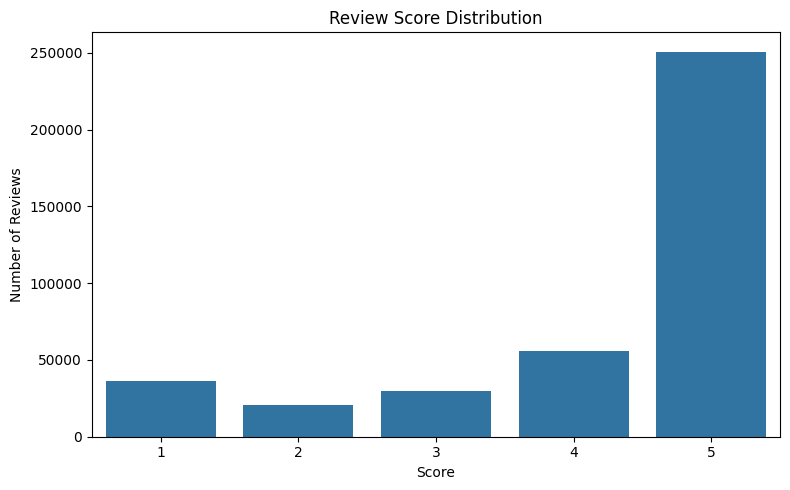

In [6]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Score"
)

plt.title("Review Score Distribution")
plt.xlabel("Score")
plt.ylabel("Number of Reviews")

plt.tight_layout()
plt.show()

## 7. Define Input and Target

We separate the dataset into:

### X
Review text used as input to the model.

### y
Review score used as the target/output.

The goal is:

Text → Score

In [7]:
X = df["Text"].astype(str)
y = df["Score"].astype(int)

print("Number of reviews:", len(X))
print("Number of scores:", len(y))

Number of reviews: 393675
Number of scores: 393675


## 8. Split the Dataset

